Import file

In [ ]:
from torch import nn
import numpy as np
import argparse
import matplotlib.pyplot as plt
import torch.nn.functional as F
#import pandas as pd # this module is useful to work with tabular data
#import random # this module will be used to select random samples from a collection
#import os # this module will be used just to create directories in the local filesystem
import torch
import torch.optim as optim
#import torchvision
#from torchvision import datasets, transforms, models
#from torchvision.models import resnet50, ResNet50_Weights, resnet18, ResNet18_Weights, resnet152, ResNet152_Weights
#from torch.utils.data import DataLoader, Dataset, SubsetRandomSampler, random_split
#from torch import nn

# Maximum Likelihood Detection in an AWGN Channel

For an AWGN channel, the received signal is

$$
y = x_i + n
$$


where:

- $x_i$ is a candidate transmitted symbol
- $n \sim \mathcal{N}(0,\sigma^2)$ is additive white Gaussian noise
- $y$ is the received signal

The conditional probability density function is

$$
p(y|x_i)
=
\frac{1}{\sqrt{2\pi\sigma^2}}
\exp\left(
-\frac{(y-x_i)^2}{2\sigma^2}
\right)
$$

The Maximum Likelihood (ML) detector selects the symbol that maximizes this probability:

$$
\hat{i} = \arg\max_i p(y|x_i)
$$

Since the term

$$
\frac{1}{\sqrt{2\pi\sigma^2}}
$$

is constant for all candidate symbols, it can be ignored during maximization:

$$
\hat{i}
=
\arg\max_i
\exp\left(
-\frac{(y-x_i)^2}{2\sigma^2}
\right)
$$

Because the exponential function is monotonically increasing,

$$
\hat{i}
=
\arg\max_i
\left(
-\frac{(y-x_i)^2}{2\sigma^2}
\right)
$$

Since $-1/(2\sigma^2)$ is a negative constant,

$$
\hat{i}
=
\arg\min_i
(y-x_i)^2
$$

Therefore, Maximum Likelihood detection for an AWGN channel is equivalent to choosing the symbol with the minimum squared Euclidean distance from the received signal:

$$
\boxed{
\hat{i}
=
\arg\min_i
(y-x_i)^2
}
$$

In [ ]:
def get_max_idx_loglikelihood(y, x):
    # maxL for AWGN channel
    """
    Maximum Likelihood decoder for AWGN channel.
    y: received vector (1D, length 7)
    x: codebook matrix (N x 7) in ±1 BPSK
    Returns index of closest codeword (min squared Euclidean distance).
    Maximizing likelihood ↔ minimizing squared Euclidean distance. That's all this function computes.
    """
    N = np.size(x, 0)
    distances = np.zeros((N, 1))
    for i in range(N):
        # TODO
        distances[i] = np.sum((y - x[i, :]) ** 2)
    return np.argmin(distances)

**from_zero_mean_bits_to_digit:** converts binary bits represented as -1 and +1 into their corresponding decimal numbers (digits).

In [ ]:
def from_zero_mean_bits_to_digit(x, B):
    # convert to binary representation
    x = (x + (B-1)) / 2  # bits in (-1,1) gets transformed in (0,1)
    N = np.size(x, 0)
    d = np.size(x, 1)
    digits = np.zeros((N, 1))
    for i in range(d):
        digits[:,0]+=x[:,i]*2**[d-1-i]
    return digits

from_digit_to_zero_mean_bits: converts decimal numbers (digits) into binary vectors represented as -1 and +1.

In [ ]:
def from_digit_to_zero_mean_bits(x, k):
    # convert from digit to zero mean
    M = len(x)
    output = np.zeros((M, k))
    for idx, i in enumerate(x):
        bits = np.array([(i >> (k - 1 - b)) & 1 for b in range(k)], dtype=float)
        output[idx, :] = bits
    output = 2 * output - 1
    return output

**Neural network as Decoder**
In here Given a noisy 7-number signal, the classifier determines which of the 16 possible symbols (0–15) was originally transmitted. Jere it will helps to  automatic parameter tracking, .train() and .eval() modes, .parameters() for optimizer, backpropagation support and save/load weights.

As the  receiver codeword input is 7, it generate 64 output. Hidden layer — 64 inputs → 64 outputs, Learns deeper patterns from the first layer's output. At the end layer it will taje 64 code and give 16 codeword length

In [ ]:
import torch.nn as nn
class Classifier(nn.Module):
    def __init__(self, input_dim, output_dim):
        """
        Fully-connected neural decoder: 7 → 64 → 64 → 16 (ReLU activations).
        """
        super(Classifier, self).__init__()

        # Design the architecture
        # TOD
        self.main = nn.Sequential(
        nn.Linear(input_dim, 64),
        nn.ReLU(), #hidden layer
        nn.Linear(64, 64),
        nn.ReLU(),# hidden layer
        nn.Linear(64, output_dim),
        )
    def forward(self, input_tensor):
        return self.main(input_tensor)


# **NeuralDecoder**
NeuralDecoder is a class that builds and configures a neural-network-based decoder for a Hamming(7,4) communication system. When an object of this class is created, it first defines the input size (7 received bits) and the number of possible output symbols (16, corresponding to all possible 4-bit messages). It then uses the given Eb/N0 value to calculate the noise level of the communication channel, which determines how much Gaussian noise is added to transmitted signals during training. Next, it creates a Classifier neural network that learns to identify which of the 16 possible messages was originally sent from a noisy 7-bit received codeword. The class also sets up an Adam optimizer to update the network weights during training and a CrossEntropyLoss function to measure prediction errors. Overall, the NeuralDecoder class prepares all the components required to train and use a neural network for decoding noisy Hamming-coded messages.


## AWGN Noise Standard Deviation
In a digital communication system, noise introduced by the channel is often modeled as Additive White Gaussian Noise (AWGN). The amount of noise added to the transmitted signal is controlled by the noise standard deviation, denoted by σ.;
$$
\sigma = \sqrt{\frac{1}{2R \cdot EbN0_{linear}}}
$$

where:

- $\sigma$ = standard deviation of the Gaussian noise  
- $R$ = code rate of the error-correcting code  
- $Eb/N_0$ = energy per information bit divided by noise power spectral density  
- $EbN0_{linear}$ = $Eb/N_0$ converted from decibels (dB) to linear scale  

	​
### Interpretation

- Higher $Eb/N_0$ → smaller $\sigma$ → less noise → cleaner signal  
- Lower $Eb/N_0$ → larger $\sigma$ → more noise → noisy signal  


 ## Hamming Code Rate

$$
R=\frac{4}{7}
$$

The Hamming(7,4) code converts 4 information bits into a 7-bit codeword. The code rate \(R\) represents the ratio of useful information bits to transmitted bits. A lower code rate provides more redundancy for error correction.

## Eb/N0 Conversion

$$
EbN0_{linear}=10^{\frac{EbN0_{dB}}{10}}
$$

The signal-to-noise ratio is often specified in decibels (dB). This formula converts the value from dB to linear scale, which is required for noise calculations in the communication system.

## AWGN Noise Standard Deviation

$$
\sigma=\sqrt{\frac{1}{2R\cdot EbN0_{linear}}}
$$

This formula calculates the standard deviation of the Additive White Gaussian Noise (AWGN) added to the transmitted signal. A higher Eb/N0 results in a smaller noise standard deviation, producing a cleaner communication channel.

## Number of Classes

$$
M=2^4=16
$$

Since the original message contains 4 bits, there are \(2^4 = 16\) possible messages. The neural network therefore performs a 16-class classification task, where each class corresponds to one possible 4-bit message.

## Cross Entropy Loss

$$
L=-\sum_{i=1}^{M} y_i \log(\hat{y}_i)
$$

Cross-entropy loss measures the difference between the true class and the probability distribution predicted by the neural network. During training, the objective is to minimize this loss so that the classifier can correctly identify the transmitted message from noisy received signals.

During training:

Low loss → predictions are close to correct class
High loss → predictions are far from correct class

Classifier (Neural Network Decoder)

The classifier is a neural network that takes the received noisy 7-bit signal as input and predicts which of the 16 possible messages was transmitted. It learns to extract patterns from noisy data and map them to the correct class label (0–15). During training, the classifier adjusts its internal weights to improve decoding accuracy.

In this system, the classifier performs a 16-class classification task, where each output neuron represents one possible 4-bit message.

Optimizer (Adam)

The optimizer is responsible for updating the neural network weights during training. In this test, the Adam optimizer is used, which is an advanced gradient-based optimization algorithm.

It uses gradients computed from backpropagation to adjust the classifier’s parameters in a way that reduces the loss. The learning rate controls how large each update step is.

In simple terms, the optimizer acts like a “learning engine” that improves the classifier after each training step.



In [ ]:
class NeuralDecoder():
    def __init__(self, EbN0):

        self.input_dim = 7
        self.EbN0 = EbN0
        self.M = 16

        # Noise std based on EbN0 in dB
        EbN0_lin = 10 ** (EbN0 / 10.0)
        R = 4.0 / 7.0
        self.eps = np.sqrt(1.0 / (2.0 * R * EbN0_lin))
        self.classifier = Classifier(input_dim=self.input_dim, output_dim=self.M)

        self.optimizer = optim.Adam(self.classifier.parameters(), lr=0.01)

        self.loss_fn = nn.CrossEntropyLoss()


##Define the generator matrix G_7_4
A generator matrix G7,4 is used to encode a 4-bit message into a 7-bit codeword by adding 3 parity bits for error correction.

In [ ]:
    @staticmethod
    def _G_7_4():
        """Hamming(7,4) systematic generator matrix."""
        return np.array([
            [1, 0, 0, 0, 1, 0, 1],
            [0, 1, 0, 0, 1, 1, 1],
            [0, 0, 1, 0, 1, 1, 0],
            [0, 0, 0, 1, 0, 1, 1],
        ], dtype=float)

**Train Function**
This function generates random 4-bit messages, encodes them using Hamming(7,4), adds AWGN noise to simulate a real communication channel, feeds the noisy signals into the neural network classifier, computes the cross-entropy loss against the original messages, and updates the model weights using backpropagation with the Adam optimizer to improve decoding accuracy over time.

Step 1: Generate Random Source Symbols

Random source symbols are generated from:

$$
s \in {0,1,\ldots,15}
$$

Since the Hamming (7,4) code contains 4 information bits:

$$
M = 2^4 = 16
$$

possible messages exist.

Each symbol is converted into a 4-bit binary message:

$$
\mathbf{u}=[u_1,u_2,u_3,u_4]
$$

Step 2: Hamming (7,4) Encoding

The information bits are encoded using the generator matrix (G):

$$
\mathbf{c}=\mathbf{u}G \pmod 2
$$

where:

- $\mathbf{u}$ = 4-bit information vector
- $\mathbf{c}$ = 7-bit codeword

The encoded bits provide error-correction capability.

Step 3: BPSK Modulation

The encoded bits are mapped to BPSK symbols:

$$
x_i = 2c_i - 1
$$

Thus,

$$
0 \rightarrow -1
$$

$$
1 \rightarrow +1
$$

forming the transmitted vector:

$$
\mathbf{x}
$$

Step 4: AWGN Channel

The transmitted signal passes through an Additive White Gaussian Noise (AWGN) channel:

$$
\mathbf{y}=\mathbf{x}+\epsilon\mathbf{n}
$$

where:

$$(\mathbf{y})$$ = received signal
$$(\mathbf{x})$$ = transmitted signal
$$(\epsilon)$$ = noise scaling factor
$$(\mathbf{n}\sim N(0,1))$$
Step 5: Neural Network Forward Pass

The received vector is fed into the neural decoder:

$$
\mathbf{z}=f_{\theta}(\mathbf{r})
$$

where:

$$(f_{\theta})$$ represents the neural network
$$(\mathbf{z})$$ contains the output logits for all 16 possible messages

The output layer contains 16 neurons corresponding to the 16 possible source symbols.

Step 6: Cross-Entropy Loss

The network is trained using Cross-Entropy Loss:

$$
L=-\sum_{i=1}^{M} y_i \log(\hat{y}_i)
$$

where:

$$(y_i)$$ is the true label
$$(\hat{y}_i)$$ is the predicted probability
$$(M=16)$$ classes

The loss measures how far the network prediction is from the correct symbol.

Step 7: Backpropagation

The gradients of the loss with respect to the network parameters are computed:

$$
\frac{\partial L}{\partial \theta}
$$

using backpropagation.

Step 8: Weight Update

The optimizer updates the network parameters:

$$\theta_{old}$$

$$\eta$$
$$\frac{\partial L}{\partial \theta}
$$

where:

$$(\theta)$$ - represents network weights
$$(\eta)$$ - the learning rate

This process reduces the loss and improves decoding accuracy.

Step 9: Training Loss Monitoring

The loss value is stored after every epoch:

$$
L^{(1)},L^{(2)},\ldots,L^{(epochs)}
$$

A decreasing loss indicates that the neural decoder is learning successfully.

Output

After training, the neural network learns a mapping:

$$
\mathbf{r}
\rightarrow
\hat{s}
$$

where $\hat{s}$ is the predicted transmitted symbol. The trained decoder can then be evaluated using the Bit Error Rate (BER) during the testing phase.

##test()##
The test() function evaluates how well your neural decoder performs compared with an optimal Maximum Likelihood (ML) decoder. It run both decoders on unseen noisy data and measure how many bits each one gets wrong. This function input 1000 random samples and return the Bit Error Rate (BER).

Step 1: Generate Test Messages

Random symbols are generated from the set:

$$
s \in {0,1,\ldots,15}
$$

Since the Hamming (7,4) code contains 4 information bits, there are:

$$
M = 2^4 = 16
$$

possible messages.

Each symbol is converted into a 4-bit binary vector:

$$
\mathbf{u}=[u_1,u_2,u_3,u_4]
$$

Step 2: Encode Messages

The information bits are encoded using the Hamming (7,4) generator matrix (G):

$$
\mathbf{c}=\mathbf{u}G \pmod 2
$$

where (\mathbf{c}) is the 7-bit codeword.

Step 3: BPSK Modulation

The encoded bits are mapped using Binary Phase Shift Keying (BPSK):

$$
x_i = 2c_i - 1
$$

which gives:

$$
0 \rightarrow -1
$$

$$
1 \rightarrow +1
$$

forming the transmitted vector (\mathbf{x}).

Step 4: AWGN Channel

Noise is added to the transmitted signal:

$$
\mathbf{r}=\mathbf{x}+\epsilon\mathbf{n}
$$

where:

(\mathbf{r}) is the received vector,
(\epsilon) controls the noise level,
(\mathbf{n}\sim N(0,1)).
Step 5: Neural Decoder

The received vector is passed through the trained neural network:

$$
\mathbf{y}=f_{\theta}(\mathbf{r})
$$

The predicted symbol is obtained by selecting the class with the highest output score:

$$
\hat{s}_{ND}=\arg\max_j y_j
$$

The predicted symbol is then converted back into a 4-bit binary message.

Step 6: Maximum Likelihood Decoder

All valid Hamming codewords are stored in a codebook.

For each received vector, the Euclidean distance to every valid codeword is calculated:

$$
d_i=|\mathbf{r}-\mathbf{x}_i|^2
$$

The ML decoder chooses the codeword with the smallest distance:

$$
\hat{s}_{ML}=\arg\min_i d_i
$$

Step 7: Bit Error Calculation

The true information bits are compared with the predicted bits.

For the Neural Decoder:

$$
e_{ND}=\sum_{j=1}^{4}|u_j-\hat{u}_{ND,j}|
$$

For the ML Decoder:

$$
e_{ML}=\sum_{j=1}^{4}|u_j-\hat{u}_{ML,j}|
$$

Step 8: Bit Error Rate (BER)

The BER of the Neural Decoder is:

$$
BER_{ND}=\frac{\sum e_{ND}}{N \times 4}
$$

The BER of the ML Decoder is:

$$
BER_{ML}=\frac{\sum e_{ML}}{N \times 4}
$$

where (N) is the number of test samples.

Output

The function returns:

$$
(BER_{ND}, BER_{ML})
$$

A neural decoder performs well when its BER approaches the BER of the Maximum Likelihood decoder, which represents the optimal decoding performance for an AWGN channel.

Streaming output truncated to the last 5000 lines.
[epoch 10/500] loss: 1.0073
[epoch 11/500] loss: 0.8758
[epoch 12/500] loss: 0.7706
[epoch 13/500] loss: 0.6607
[epoch 14/500] loss: 0.4916
[epoch 15/500] loss: 0.5527
[epoch 16/500] loss: 0.4531
[epoch 17/500] loss: 0.4400
[epoch 18/500] loss: 0.5626
[epoch 19/500] loss: 0.4402
[epoch 20/500] loss: 0.5020
[epoch 21/500] loss: 0.2876
[epoch 22/500] loss: 0.4364
[epoch 23/500] loss: 0.3951
[epoch 24/500] loss: 0.4739
[epoch 25/500] loss: 0.3979
[epoch 26/500] loss: 0.4348
[epoch 27/500] loss: 0.3546
[epoch 28/500] loss: 0.5799
[epoch 29/500] loss: 0.5563
[epoch 30/500] loss: 0.3648
[epoch 31/500] loss: 0.4622
[epoch 32/500] loss: 0.4007
[epoch 33/500] loss: 0.4631
[epoch 34/500] loss: 0.4398
[epoch 35/500] loss: 0.3065
[epoch 36/500] loss: 0.4889
[epoch 37/500] loss: 0.3532
[epoch 38/500] loss: 0.3742
[epoch 39/500] loss: 0.3341
[epoch 40/500] loss: 0.3776
[epoch 41/500] loss: 0.3398
[epoch 42/500] loss: 0.4039
[epoch 43/500] loss: 0.35

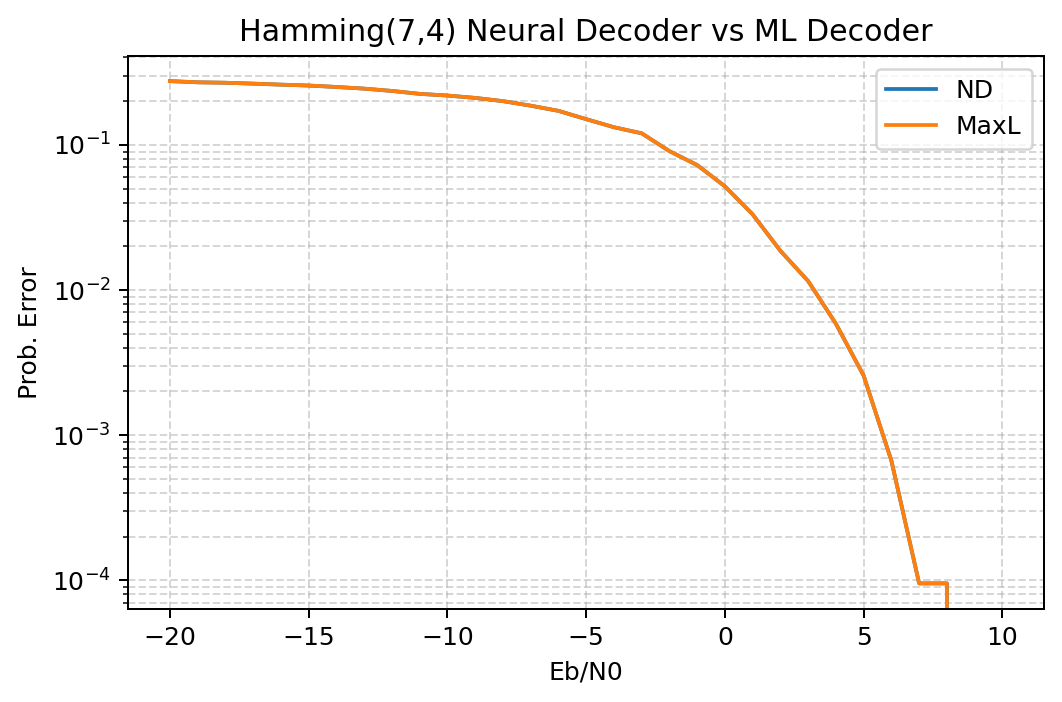

In [ ]:
import argparse
import numpy as np
import torch

class NeuralDecoder():
    def __init__(self, EbN0):

        self.input_dim = 7
        self.EbN0 = EbN0
        self.M = 16

        # Noise std based on EbN0 in dB
        EbN0_lin = 10 ** (EbN0 / 10.0)
        R = 4.0 / 7.0
        self.eps = np.sqrt(1.0 / (2.0 * R * EbN0_lin))
        self.classifier = Classifier(input_dim=self.input_dim, output_dim=self.M)

        self.optimizer = optim.Adam(self.classifier.parameters(), lr=0.01)

        self.loss_fn = nn.CrossEntropyLoss()

    @staticmethod
    def _G_7_4():
        """Hamming(7,4) systematic generator matrix."""
        return np.array(
            [[1, 0, 0, 0, 1, 0, 1],
            [0, 1, 0, 0, 1, 1, 1],
            [0, 0, 1, 0, 1, 1, 0],
            [0, 0, 0, 1, 0, 1, 1],
        ], dtype=float)

    def train(self, epochs, batch_size=40):
        """
        Train the model using cross -entropy.
        """
        self.classifier.train()
        M = 16
        # define the generator matrix G_7_4

        G_7_4 = self._G_7_4()
        full_loss = np.zeros((epochs,1))
        # start training
        for epoch in range(epochs):
            # Random source symbols
            symbols = np.random.randint(0, M, size=batch_size)
            # Source encode → 4 bits in {0,1}
            bits_4 = 0.5 * (from_digit_to_zero_mean_bits(symbols, 4) + 1)

            # Hamming(7,4) channel encode: c = b·G mod 2
            codewords = np.mod(np.matmul(bits_4, G_7_4), 2)
            # Generate data to transmit
            data_tx = 2 * codewords - 1 # # BPSK modulate: {0,1} → {+1,-1}
            # Simulate the AWGN noise and produce the received samples
            data_rx = data_tx + self.eps * np.random.randn(*data_tx.shape) # # AWGN channel: y = x + n
            # What are the labels?
            y = torch.tensor(symbols, dtype=torch.long)  # Labels for cross-entropy are the integer symbol indices

            # Train classifier
               # Forward + backward
            data_rx_t = torch.tensor(data_rx, dtype=torch.float32)
            self.optimizer.zero_grad()
            logits = self.classifier(data_rx_t) #Passes received data through the neural networ
            loss = self.loss_fn(logits, y) #Calculates cross-entropy loss.
            loss.backward() #Computes gradients of the loss with respect to all network parameters.
            self.optimizer.step() #Updates network weights using the computed gradients.

            full_loss[epoch] = loss.detach().numpy() #Creates an array to store the loss value from each epoch.
            print(f"[epoch {epoch+1}/{epochs}] loss: {loss.item():.4f}")
    def test(self, test_size=1000): #Tests the decoder using 1000 random samples
        self.classifier.eval()
        eps = self.eps
        BER = np.zeros((1, test_size)) #arrays to store bit error
        BER_maxL = np.zeros((1, test_size))

        G_7_4 = self._G_7_4 ()
        random_test_symbol= np.random.randint(0, 16, size=test_size)
        test_bits_4 = 0.5 * (from_digit_to_zero_mean_bits(random_test_symbol, 4) + 1) # convert symbol to 4 bits message
        test_codewords = np.mod(np.matmul(test_bits_4, G_7_4), 2)
        test_data_tx = 2 * test_codewords - 1 #BPSK modulation
        test_data_rx = test_data_tx + self.eps * np.random.randn(*test_data_tx.shape) #Pass through AWGN channel

        # Produce tx and rx samples
        # TODO

        alphabet = range(16) # Build the complete codebook
        training_samples_1 = 0.5 * (from_digit_to_zero_mean_bits(alphabet, 4) + 1)
        training_samples_F = np.matmul(training_samples_1, G_7_4)
        training_samples = np.mod(training_samples_F, [2])
        training_samples = 2 * training_samples - 1

        R = self.classifier(torch.tensor(test_data_rx, dtype=torch.float32)) # Corrected data_rx to test_data_rx and added torch.tensor conversion
        R = R.detach().numpy()

        # Extract metrics for each transmitted sample
        for i in range(test_size):
            # Write the code to obtain the bit-error-rate for the neural decoder and the classical maximum-likelihood
            # neural decoder: argmax of logits
            max_idx = np.argmax(R[i, :])
            # ML decoder: nearest codeword in Euclidean distance
            max_idx_LL = get_max_idx_loglikelihood(test_data_rx[i, :], training_samples)
             # True 4-bit word (in {0,1})
            true_bits = 0.5 * (from_digit_to_zero_mean_bits([random_test_symbol[i]], 4) + 1) # Corrected symbols_test to random_test_symbol
            nd_bits = 0.5 * (from_digit_to_zero_mean_bits([max_idx], 4) + 1)
            ml_bits = 0.5 * (from_digit_to_zero_mean_bits([max_idx_LL], 4) + 1)

            # Sum of bit errors for this sample
            BER[0, i] =  np.sum(np.abs(nd_bits - true_bits))
            BER_maxL[0, i] = np.sum(np.abs(nd_bits - true_bits))

        return np.sum(BER)/(test_size*self.input_dim), np.sum(BER_maxL)/(test_size*self.input_dim)



if __name__ == '__main__':

    #parser = argparse.ArgumentParser()
    #parser.add_argument('--batch_size', default=256)
    #parser.add_argument('--epochs', default=500)
    #parser.add_argument('--test_size', default=3000)
    #args = parser.parse_args()
    #test_size = int(args.test_size)
    batch_size=256
    epochs=500
    test_size=3000

    SNR_dB = range(-20,11)

    ber_total = np.zeros((len(SNR_dB),1))
    ber_total_LL = np.zeros((len(SNR_dB),1))


    j = 0
    for SNR in SNR_dB:
        print(f'Actual SNR is:{SNR}')
        # Initialize dDIME
        ND = NeuralDecoder(SNR)
        # Train
        #ND.train(epochs=int(args.epochs), batch_size=int(args.batch_size))
        ND.train(epochs=epochs, batch_size=batch_size)

        # Test
        ND.test(test_size=test_size)
        ber, ber_maxL = ND.test(test_size=test_size)
        ber_total[j,0] = ber
        ber_total_LL[j,0] = ber_maxL

        del ND
        j = j+1

    plt.figure(figsize=(6, 4), dpi=180)
    plt.semilogy(SNR_dB, ber_total, label='ND')
    plt.semilogy(SNR_dB, ber_total_LL, label='MaxL')

    plt.xlabel("Eb/N0")
    plt.ylabel("Prob. Error")
    plt.title("Hamming(7,4) Neural Decoder vs ML Decoder")
    plt.legend()
    plt.grid(True, which='both', ls='--', alpha=0.5)
    plt.tight_layout()
    plt.show()



##Conclusion
According to the result, neural Decoder and maximum likelihood almost perfectly align. This emphasise that neural decoder has sucessfully learnt the optimal decoder rules. The performances nearly align with maximum likelihood decoder. The loss is relatively low loss in neural network. The graph shows thatprobability of error decrease when signal to noise ratio increases. This emphasise quality of the signal drops the probability of error. The conclusion of the study is neural network successfully learns the Maximum Likelihood decoding rule for the Hamming(7,4) code.
